# Expert Labels

In [1]:
import scripts
import numpy as np

In [47]:
colors = ['#0283F8', '#0078F3', '#3369E8', '#605BDA', "#7D49CB",
          "#9331B7", "#A918A8", "#C4009A", "#DA008B", "#EA007B",
          "#F7006A", "#FF0059"]

In [2]:
import sys
import os
import warnings
from contextlib import contextmanager

@contextmanager
def suppress_stdout_stderr():
    """A context manager that redirects stdout and stderr to devnull"""
    # Save the original stdout and stderr
    original_stdout = sys.stdout
    original_stderr = sys.stderr
    
    # Open the null device
    with open(os.devnull, 'w') as devnull:
        # Redirect stdout and stderr
        sys.stdout = devnull
        sys.stderr = devnull
        try:
            yield # This is where the code inside the 'with' block will run
        finally:
            # IMPORTANT: Always restore the original streams
            sys.stdout = original_stdout
            sys.stderr = original_stderr

import csv
import os

def append_dict_to_csv(csv_filepath, data_dict):
    """
    Appends a dictionary as a new row to a CSV file.

    - If the CSV file does not exist, it will be created, and the
      dictionary keys will be used as the header row.
    - If the CSV file exists, the dictionary values are appended
      as a new row. The keys are assumed to match the header.

    Args:
        csv_filepath (str): The path to the CSV file.
        data_dict (dict): The dictionary to write to the CSV.
    """
    # Check if the file exists to determine if we need to write the header
    file_exists = os.path.exists(csv_filepath)

    # Use 'a' mode for appending, which creates the file if it doesn't exist.
    # newline='' is critical to prevent blank rows from being written.
    with open(csv_filepath, 'a', newline='', encoding='utf-8') as f:
        # The fieldnames are the dictionary keys.
        # It's important that all dictionaries you write have the same keys.
        fieldnames = data_dict.keys()
        
        # Create a DictWriter object
        writer = csv.DictWriter(f, fieldnames=fieldnames)

        # If the file is new, write the header row
        if not file_exists:
            writer.writeheader()

        # Write the dictionary as a new row
        writer.writerow(data_dict)

In [3]:
# Load the data
def load_dataset(dataset="adult",expert_accuracy=0.75,seed=42):
    match dataset:
        case "adult":
            df,y,feature_names = scripts.datasets.adult_load_and_preprocess()
        case "plant":
            df,y,feature_names = scripts.datasets.plant_load_and_preprocess()
        case "telescope":
            df,y,feature_names = scripts.datasets.telescope_load_and_preprocess()
        case "wine":
            df,y,feature_names = scripts.datasets.wine_load_and_preprocess()
        case "star":
            df,y,feature_names = scripts.datasets.star_load_and_preprocess()
        case "cancer":
            df,y,feature_names = scripts.datasets.cancer_load_and_preprocess()
        case "diabetes":
            df,y,feature_names = scripts.datasets.diabetes_load_and_preprocess()
        case _:
            print("ERROR: dataset has to be one of [adult, plant]")
            return
            
    np.random.seed(seed)
    feature_weights = {feature: [np.random.randint(0,2), 0] for feature in feature_names}
    
    expert = scripts.expert.simulate_expert(
        X_processed=df,
        y_true=y,
        feature_weights_config=feature_weights,
        target_fnr=1-expert_accuracy, 
        target_fpr=1-expert_accuracy,
        expert_alpha=30,
        expert_seed=seed
    )
    
    human_predictions = expert.predict(df,y)
    dataset = scripts.datasets.Dataset(df.values,y,human_predictions, random_seed=seed)
    return expert, dataset, feature_names

In [14]:
import torch
from defer.helpers.metrics import *
from defer.networks.linear_net import *
from defer.networks.non_linear_net import *
import torch.optim as optim
from defer.methods.realizable_surrogate import *
from defer.baselines.lce_surrogate import *
from defer.baselines.one_v_all import *
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import importlib
import os

def train_l2d_model(dataset, expert,method = "realizable_surrogate"):
    # Set up model training parameters
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    optimizer = optim.Adam
    scheduler = None
    lr = 1e-2
    total_epochs = 100
    # Create and train model
    model = NonLinearNet(dataset.d, 3).to(device)  # positive, negative, and defer
    # Instantiate method
    match method:
        case "realizable_surrogate":
            L2D = RealizableSurrogate(1, 300, model, device, True)
        case "crossentropy_surrogate": #lce
            L2D = LceSurrogate(1, 300, model, device)
        case "one_vs_all":
            L2D = OVASurrogate(1, 300, model, device)
        case _:
            print("Model has to be one of: realizable_surrogate, crossentropy_surrogate or one_vs_all")
            return None, {}, None, []
    L2D.fit_hyperparam(
        dataset.data_train_loader,
        dataset.data_val_loader,
        dataset.data_test_loader,
        epochs=total_epochs,
        optimizer=optimizer,
        scheduler=scheduler,
        lr=lr,
        verbose=False,
        test_interval=5,
    )
    # Get metrics
    metrics = compute_deferral_metrics(L2D.test(dataset.data_test_loader))
    factual_df, factuals = scripts.utils.build_factual_df(L2D,dataset,expert,defer_only=True)
    return L2D, metrics, factual_df, factuals

In [5]:
def obtain_counterfactuals(l2d,factuals,factual_df,metrics,expert ):
    perturbations, counter_df = scripts.counterfactual.find_defer_counterfactuals_parallel(
        model=l2d.model,
        test_x=factuals,
        threshold_rej=0,
        n_jobs=-1 # Use all available cores
    )
    
    counter_df = scripts.utils.probe_counterfactuals(counter_df,perturbations,factuals,expert,l2d)
    df_merged = factual_df.join(counter_df[["cfs_entropy","cfs_expected_expert_err"]],how="inner")
    
    isTypeI = df_merged["entropy"] > df_merged["cfs_entropy"]
    isTypeII = df_merged["cfs_expected_expert_err"] > df_merged["expected_expert_err"]
    #model_was_correct = df_merged["model_pred"] == df_merged["label"]
    #expert_was_correct = df_merged["expert_pred"] == df_merged["label"]
    
    metrics["n_type1"] = np.sum(isTypeI)
    metrics["n_type2"] = np.sum(isTypeII)
    metrics["n_only_type1"] = np.sum(isTypeI & ~isTypeII)
    metrics["n_only_type2"] = np.sum(isTypeII & ~isTypeI)
    metrics["n_defer"] = df_merged.shape[0]
    return metrics,df_merged, perturbations

In [8]:
import time

def run_expert_iteration(dataset_name="adult", method="realizable_surrogate",max_retries=10):
    seed = int(time.time())
    max_retries = 10 # Safety measure to prevent infinite loops

    expert_accuracies = [0.6,0.625, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9]
    i = 0 # Our manual loop index

    while i < len(expert_accuracies):
        expert_acc = expert_accuracies[i]
        print(f"Running: {expert_acc} accuracy on {dataset_name} using {method} with seed {seed}...")
        with suppress_stdout_stderr():
            expert, dataset, feature_names = load_dataset(dataset=dataset_name, expert_accuracy=expert_acc, seed=seed)
            RS, metrics, factual_df, factuals = train_l2d_model(dataset, expert,method = method) ### method!!!
        if len(factuals)==0: # Or `if factuals.empty:` for pandas DataFrames
            print(f"--> No factuals found. Changing seed and retrying for expert_acc={expert_acc}...")
            seed = int(time.time()) # Change the seed and try again
            continue
        with suppress_stdout_stderr():
            metrics, counter_df, perturbations = obtain_counterfactuals(RS, factuals,factual_df, metrics, expert)
        if metrics["n_type2"]==0:
            print(f"--> No Type 2 defer. Changing seed and retrying for expert_acc={expert_acc}...")
            seed = int(time.time()) # Change the seed and try again
            continue
        append_dict_to_csv(f"results/validation_expert_{dataset_name}_{method}.csv", metrics)
        i += 1

In [15]:
for i in range(10):
    for dataset_name in ["adult","plant","wine"]:
        for method in ["realizable_surrogate", "crossentropy_surrogate", "one_vs_all"]:
            print("-"*10+f" Iteration {i+1}/10"+"-"*10)
            run_expert_iteration(dataset_name,method)

---------- Iteration 1/10----------
Running: 0.6 accuracy on adult using realizable_surrogate with seed 1753722375...
Running: 0.625 accuracy on adult using realizable_surrogate with seed 1753722375...
Running: 0.65 accuracy on adult using realizable_surrogate with seed 1753722375...
--> No factuals found. Changing seed and retrying for expert_acc=0.65...
Running: 0.65 accuracy on adult using realizable_surrogate with seed 1753722902...
Running: 0.7 accuracy on adult using realizable_surrogate with seed 1753722902...
Running: 0.75 accuracy on adult using realizable_surrogate with seed 1753722902...
Running: 0.8 accuracy on adult using realizable_surrogate with seed 1753722902...
Running: 0.85 accuracy on adult using realizable_surrogate with seed 1753722902...
Running: 0.9 accuracy on adult using realizable_surrogate with seed 1753722902...
---------- Iteration 1/10----------
Running: 0.6 accuracy on adult using crossentropy_surrogate with seed 1753725797...
Running: 0.625 accuracy on 

KeyboardInterrupt: 

In [78]:
run_expert_iteration("plant","one_vs_all")
run_expert_iteration("plant","one_vs_all")

Running: 0.6 accuracy on plant using one_vs_all with seed 1753801784...
Running: 0.625 accuracy on plant using one_vs_all with seed 1753801784...
Running: 0.65 accuracy on plant using one_vs_all with seed 1753801784...
Running: 0.7 accuracy on plant using one_vs_all with seed 1753801784...
Running: 0.75 accuracy on plant using one_vs_all with seed 1753801784...
Running: 0.8 accuracy on plant using one_vs_all with seed 1753801784...
Running: 0.85 accuracy on plant using one_vs_all with seed 1753801784...
Running: 0.9 accuracy on plant using one_vs_all with seed 1753801784...
Running: 0.6 accuracy on plant using one_vs_all with seed 1753802649...
Running: 0.625 accuracy on plant using one_vs_all with seed 1753802649...
Running: 0.65 accuracy on plant using one_vs_all with seed 1753802649...
Running: 0.7 accuracy on plant using one_vs_all with seed 1753802649...
Running: 0.75 accuracy on plant using one_vs_all with seed 1753802649...
Running: 0.8 accuracy on plant using one_vs_all with se

In [16]:
dfs=[]
for dataset_name in ["adult","plant","telescope"]:
    for method in ["realizable_surrogate", "crossentropy_surrogate", "one_vs_all"]:
        dfs.append(pd.read_csv(f"results/validation_expert_{dataset_name}_{method}.csv"))
        

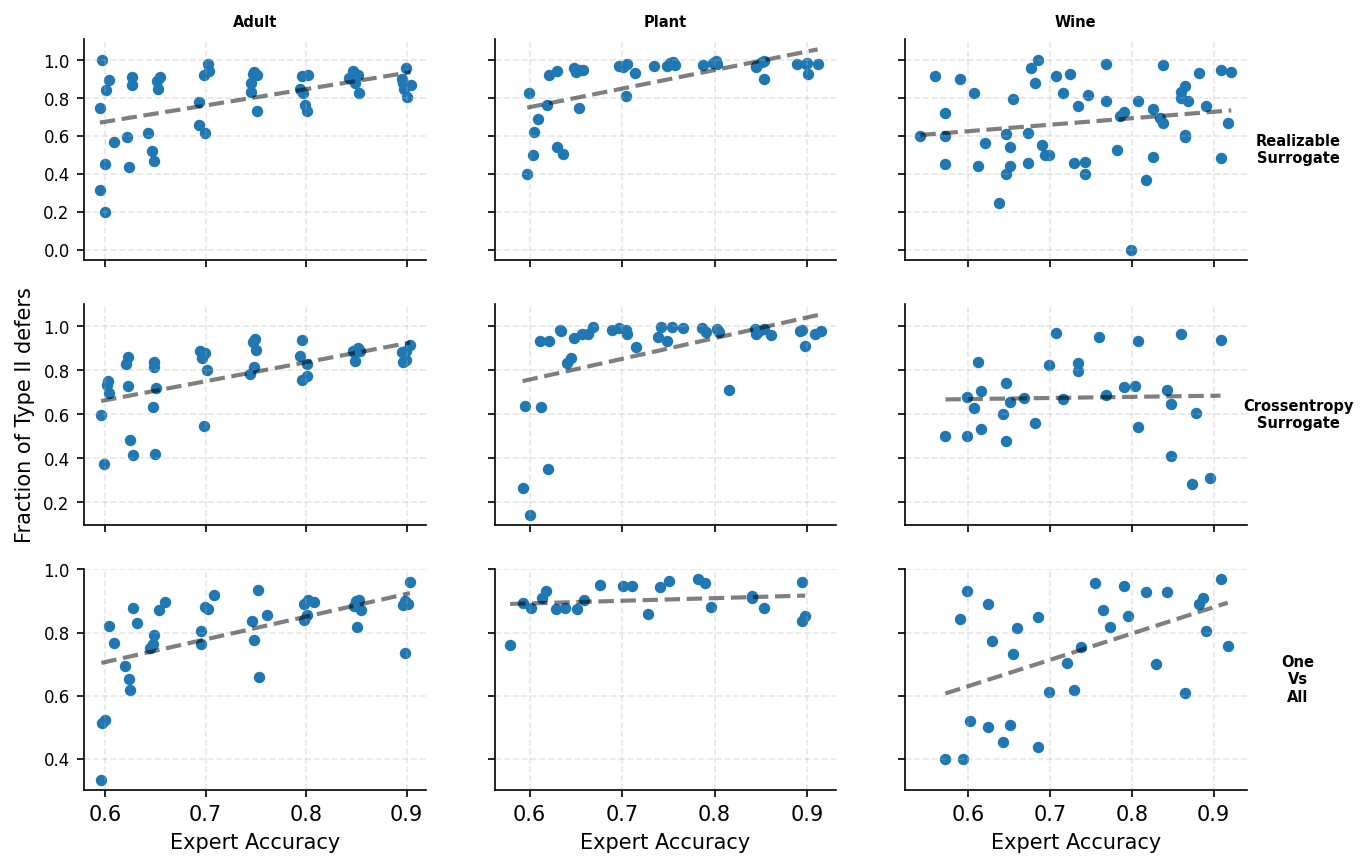

In [80]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

def add_linear_fit(ax, x, y, color='red', linestyle='--', alpha=0.8, show_equation=True):
    """
    Add a linear fit line to a matplotlib axis
    
    Parameters:
    -----------
    ax : matplotlib axis object
        The axis to plot on
    x, y : array-like
        Data points to fit
    color : str, default 'red'
        Color of the fit line
    linestyle : str, default '--'
        Line style for the fit
    alpha : float, default 0.8
        Transparency of the fit line
    show_equation : bool, default True
        Whether to show the equation and R² on the plot
    
    Returns:
    --------
    slope, intercept, r_value, p_value : float
        Linear regression parameters
    """
    # Remove any NaN values
    mask = ~(np.isnan(x) | np.isnan(y))
    x_clean = np.array(x)[mask]
    y_clean = np.array(y)[mask]
    
    if len(x_clean) < 2:
        return None, None, None, None
    
    # Perform linear regression
    slope, intercept, r_value, p_value, std_err = stats.linregress(x_clean, y_clean)
    
    # Create fit line
    x_range = np.linspace(x_clean.min(), x_clean.max(), 100)
    y_fit = slope * x_range + intercept
    
    # Plot the fit line
    ax.plot(x_range, y_fit, color=color, linestyle=linestyle, alpha=alpha, linewidth=2)
    
    # Add equation and R² to the plot
    if show_equation:
        equation_text = f'y = {slope:.3f}x + {intercept:.3f}\nR² = {r_value**2:.3f}'
        # Position text in upper left corner
        ax.text(0.05, 0.95, equation_text, transform=ax.transAxes, 
                fontsize=9, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    return slope, intercept, r_value, p_value

# Alternative version with shared axes for better comparison
datasets = ["adult","plant","wine"]
methods = ["realizable_surrogate", "crossentropy_surrogate", "one_vs_all"]

# Transposed: methods as rows, datasets as columns
fig2, axes2 = plt.subplots(len(methods), len(datasets), 
                          figsize=(10, 6.5),dpi=150,
                          sharex='col', sharey='row')

# Ensure axes is 2D
if len(methods) == 1:
    axes2 = axes2.reshape(1, -1)
if len(datasets) == 1:
    axes2 = axes2.reshape(-1, 1)

# Store fit parameters for analysis if needed
fit_results = {}

for i, method in enumerate(methods):
    for j, dataset_name in enumerate(datasets):
        # Read data
        chunk = pd.read_csv(f"results/validation_expert_{dataset_name}_{method}.csv")
        
        # Get current axis
        ax = axes2[i, j]
        
        # Create scatter plot
        scatter = ax.scatter(chunk["human_all_acc"], chunk["n_type2"]/chunk["n_defer"], 
                           alpha=1, s=20)
        
        # Add linear fit line
        slope, intercept, r_value, p_value = add_linear_fit(
            ax, 
            chunk["human_all_acc"], 
            chunk["n_type2"]/chunk["n_defer"],
            color="black",
            linestyle='--',
            alpha=0.5,
            show_equation=False
        )
        
        # Store fit results
        fit_results[f"{dataset_name}_{method}"] = {
            'slope': slope,
            'intercept': intercept,
            'r_squared': r_value**2 if r_value is not None else None,
            'p_value': p_value
        }
        
        # Set labels only on edge plots
        if i == len(methods) - 1:  # Bottom row
            ax.set_xlabel("Expert Accuracy", fontsize=10)
        if j == 0 and i == 1:  # Left column
            ax.set_ylabel("Fraction of Type II defers", fontsize=10)
        
        # Remove top and right spines
        ax.spines[["right", "top"]].set_visible(False)
        
        # Add grid for better readability
        ax.grid(True, alpha=0.3, linestyle='--')
        
        # Set title
        if i == 0:  # Top row - add dataset names
            ax.set_title(dataset_name.title(), fontsize=7, fontweight='bold')
        
        # Add method name on the left side
        if j == 2:  # Left column
            ax.text(1.15, 0.5, method.replace('_', '\n').title(), 
                   transform=ax.transAxes, 
                   rotation=0, 
                   verticalalignment='center',ha="center",
                   fontsize=7, fontweight='bold')
        ax.tick_params(axis='y', labelsize=8)

# Adjust layout to accommodate method labels on the left
#plt.tight_layout(rect=[-0.1, 0, 1, 0.95])
plt.savefig("results/expert_validation.pdf")
plt.show()

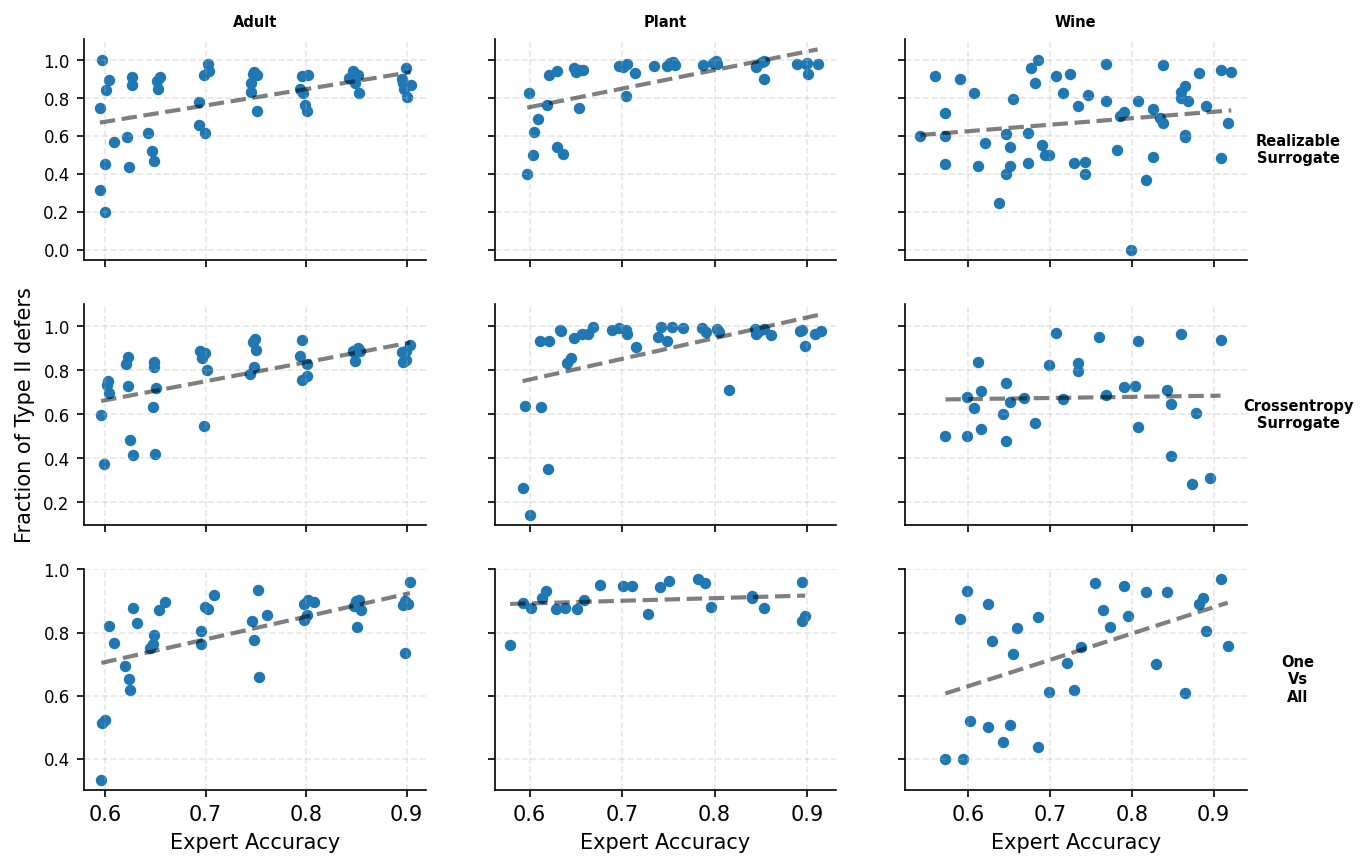

In [98]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

def add_linear_fit(ax, x, y, color='red', linestyle='--', alpha=0.8, show_equation=True):
    """
    Add a linear fit line to a matplotlib axis
    
    Parameters:
    -----------
    ax : matplotlib axis object
        The axis to plot on
    x, y : array-like
        Data points to fit
    color : str, default 'red'
        Color of the fit line
    linestyle : str, default '--'
        Line style for the fit
    alpha : float, default 0.8
        Transparency of the fit line
    show_equation : bool, default True
        Whether to show the equation and R² on the plot
    
    Returns:
    --------
    slope, intercept, r_value, p_value : float
        Linear regression parameters
    """
    # Remove any NaN values
    mask = ~(np.isnan(x) | np.isnan(y))
    x_clean = np.array(x)[mask]
    y_clean = np.array(y)[mask]
    
    if len(x_clean) < 2:
        return None, None, None, None
    
    # Perform linear regression
    slope, intercept, r_value, p_value, std_err = stats.linregress(x_clean, y_clean)
    
    # Create fit line
    x_range = np.linspace(x_clean.min(), x_clean.max(), 100)
    y_fit = slope * x_range + intercept
    
    # Plot the fit line
    ax.plot(x_range, y_fit, color=color, linestyle=linestyle, alpha=alpha, linewidth=2)
    
    # Add equation and R² to the plot
    if show_equation:
        equation_text = f'y = {slope:.3f}x + {intercept:.3f}\nR² = {r_value**2:.3f}'
        # Position text in upper left corner
        ax.text(0.05, 0.95, equation_text, transform=ax.transAxes, 
                fontsize=9, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    return slope, intercept, r_value, p_value

def plot_method_comparison(method_name, figsize=(12, 4), dpi=150,save_path=None):
    """
    Create a comparison plot for a single method across all datasets
    
    Parameters:
    -----------
    method_name : str
        Name of the method to plot (e.g., 'realizable_surrogate', 'crossentropy_surrogate', 'one_vs_all')
    figsize : tuple, default (12, 4)
        Figure size (width, height)
    dpi : int, default 150
        Figure resolution
    save_path : str, optional
        Path to save the figure. If None, figure is not saved.
    
    Returns:
    --------
    fig : matplotlib figure
        The created figure
    fit_results : dict
        Dictionary containing fit parameters for each dataset
    """
    
    datasets = ["adult", "plant", "wine"]
    
    # Create figure with subplots
    fig, axes = plt.subplots(1, len(datasets), 
                            figsize=figsize, dpi=dpi,
                            sharey=True)
    
    # Ensure axes is always a list (in case of single dataset)
    if len(datasets) == 1:
        axes = [axes]
    
    # Store fit parameters for analysis
    fit_results = {}
    
    for j, dataset_name in enumerate(datasets):
        # Read data
        chunk = pd.read_csv(f"results/validation_expert_{dataset_name}_{method_name}.csv")
        
        # Get current axis
        ax = axes[j]
        
        # Create scatter plot
        scatter = ax.scatter(chunk["human_all_acc"], chunk["n_type2"]/chunk["n_defer"], 
                           alpha=1, s=20)
        
        # Add linear fit line
        slope, intercept, r_value, p_value = add_linear_fit(
            ax, 
            chunk["human_all_acc"], 
            chunk["n_type2"]/chunk["n_defer"],
            color="black",
            linestyle='--',
            alpha=0.5,
            show_equation=False
        )
        
        # Store fit results
        fit_results[dataset_name] = {
            'slope': slope,
            'intercept': intercept,
            'r_squared': r_value**2 if r_value is not None else None,
            'p_value': p_value
        }
        
        # Set x-label for all subplots
        ax.set_xlabel("Expert Accuracy", fontsize=10)
        
        # Set y-label only for the leftmost plot
        if j == 0:
            ax.set_ylabel("Fraction of Type II defers", fontsize=10)
        
        # Remove top and right spines
        ax.spines[["right", "top"]].set_visible(False)
        
        # Add grid for better readability
        ax.grid(True, alpha=0.3, linestyle='--')
        
        # Set title with dataset name
        ax.set_title(dataset_name.title(), fontsize=12, fontweight='bold')
        
        # Format tick labels
        ax.tick_params(axis='both', labelsize=8)
    
  
    # Adjust layout
    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path)
    plt.show()
    
    return fig, fit_results

# Alternative version with shared axes for better comparison
datasets = ["adult","plant","wine"]
methods = ["realizable_surrogate", "crossentropy_surrogate", "one_vs_all"]

# Transposed: methods as rows, datasets as columns
fig2, axes2 = plt.subplots(len(methods), len(datasets), 
                          figsize=(10, 6.5),dpi=150,
                          sharex='col', sharey='row')

# Ensure axes is 2D
if len(methods) == 1:
    axes2 = axes2.reshape(1, -1)
if len(datasets) == 1:
    axes2 = axes2.reshape(-1, 1)

# Store fit parameters for analysis if needed
fit_results = {}

for i, method in enumerate(methods):
    for j, dataset_name in enumerate(datasets):
        # Read data
        chunk = pd.read_csv(f"results/validation_expert_{dataset_name}_{method}.csv")
        
        # Get current axis
        ax = axes2[i, j]
        
        # Create scatter plot
        scatter = ax.scatter(chunk["human_all_acc"], chunk["n_type2"]/chunk["n_defer"], 
                           alpha=1, s=20)
        
        # Add linear fit line
        slope, intercept, r_value, p_value = add_linear_fit(
            ax, 
            chunk["human_all_acc"], 
            chunk["n_type2"]/chunk["n_defer"],
            color="black",
            linestyle='--',
            alpha=0.5,
            show_equation=False
        )
        
        # Store fit results
        fit_results[f"{dataset_name}_{method}"] = {
            'slope': slope,
            'intercept': intercept,
            'r_squared': r_value**2 if r_value is not None else None,
            'p_value': p_value
        }
        
        # Set labels only on edge plots
        if i == len(methods) - 1:  # Bottom row
            ax.set_xlabel("Expert Accuracy", fontsize=10)
        if j == 0 and i == 1:  # Left column
            ax.set_ylabel("Fraction of Type II defers", fontsize=10)
        
        # Remove top and right spines
        ax.spines[["right", "top"]].set_visible(False)
        
        # Add grid for better readability
        ax.grid(True, alpha=0.3, linestyle='--')
        
        # Set title
        if i == 0:  # Top row - add dataset names
            ax.set_title(dataset_name.title(), fontsize=7, fontweight='bold')
        
        # Add method name on the left side
        if j == 2:  # Left column
            ax.text(1.15, 0.5, method.replace('_', '\n').title(), 
                   transform=ax.transAxes, 
                   rotation=0, 
                   verticalalignment='center',ha="center",
                   fontsize=7, fontweight='bold')
        ax.tick_params(axis='y', labelsize=8)

# Adjust layout to accommodate method labels on the left
#plt.tight_layout(rect=[-0.1, 0, 1, 0.95])
#plt.savefig("results/expert_validation.pdf")
plt.show()

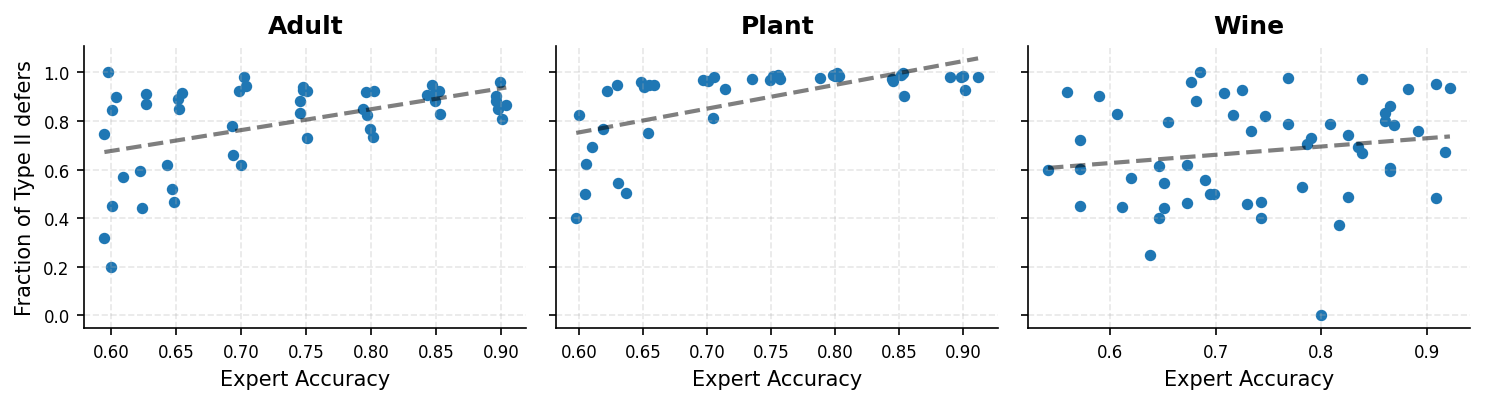

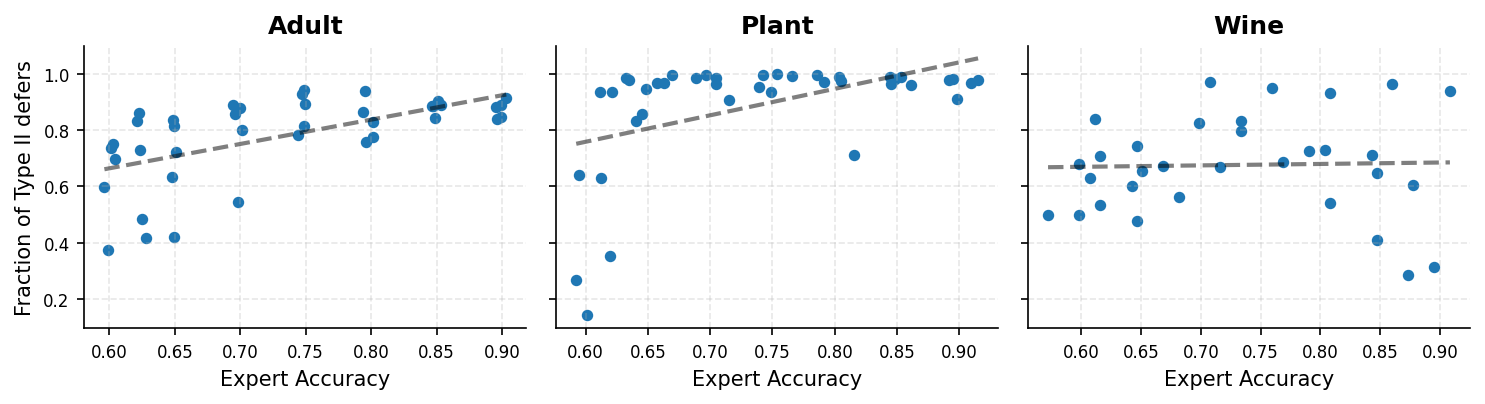

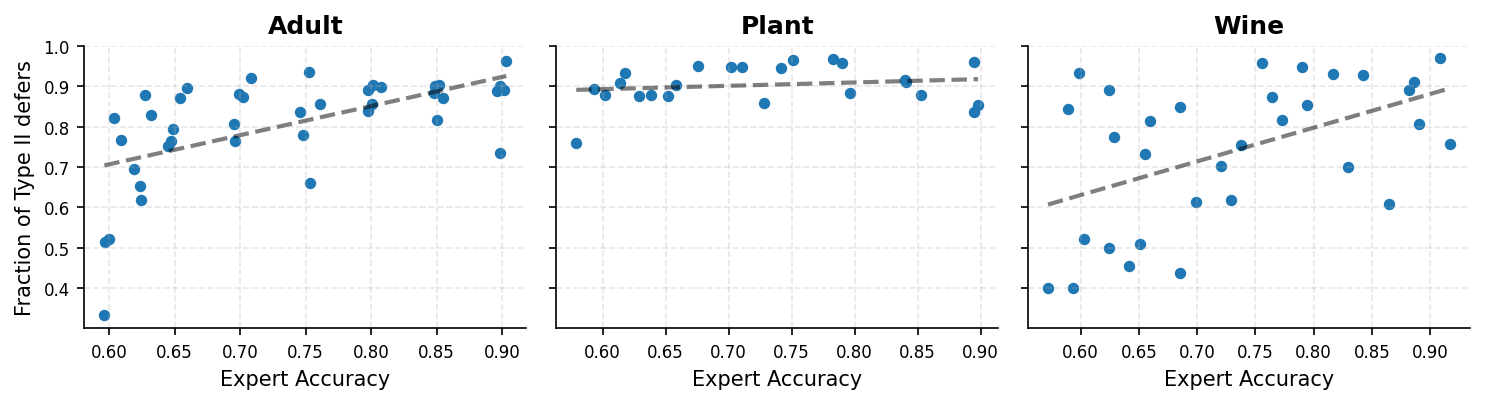

In [99]:
for method in ["realizable_surrogate","crossentropy_surrogate","one_vs_all"]:
    fig, results = plot_method_comparison(method,figsize=(10, 2.8),save_path=f"results/expert_validation_{method}.pdf")
        

In [83]:
print("\n" + "="*60)
print("LATEX TABLE")
print("="*60)

print("\nLinear Regression Results (Coefficients and P-values):")
print("\\begin{table}[h]")
print("\\centering")
print("\\caption{Linear regression results: coefficients and p-values for Type II deferrals vs Expert accuracy}")
print("\\begin{tabular}{l|cc|cc|cc}")
print("\\hline")
print("\\multirow{2}{*}{Method} & \\multicolumn{2}{c|}{Adult} & \\multicolumn{2}{c|}{Plant} & \\multicolumn{2}{c}{Wine} \\\\")
print("& Coef. & P-val & Coef. & P-val & Coef. & P-val \\\\")
print("\\hline")

for method in methods:
    method_name = method.replace('_', '\\_')  # Escape underscores for LaTeX
    row = f"{method_name}"
    
    for dataset in datasets:
        key = f"{dataset}_{method}"
        if fit_results[key]['slope'] is not None and fit_results[key]['p_value'] is not None:
            slope = fit_results[key]['slope']
            p_value = fit_results[key]['p_value']
            
            # Format coefficient
            coef_str = f"{slope:.4f}"
            
            # Format p-value
            if p_value < 0.001:
                p_str = "$<0.001$"
            else:
                p_str = f"{p_value:.4f}"
                
            row += f" & {coef_str} & {p_str}"
        else:
            row += " & N/A & N/A"
    
    row += " \\\\"
    print(row)

print("\\hline")
print("\\end{tabular}")
print("\\end{table}")
print("="*60)


LATEX TABLE

Linear Regression Results (Coefficients and P-values):
\begin{table}[h]
\centering
\caption{Linear regression results: coefficients and p-values for Type II deferrals vs Expert accuracy}
\begin{tabular}{l|cc|cc|cc}
\hline
\multirow{2}{*}{Method} & \multicolumn{2}{c|}{Adult} & \multicolumn{2}{c|}{Plant} & \multicolumn{2}{c}{Wine} \\
& Coef. & P-val & Coef. & P-val & Coef. & P-val \\
\hline
realizable\_surrogate & 0.8602 & $<0.001$ & 0.9782 & $<0.001$ & 0.3412 & 0.2056 \\
crossentropy\_surrogate & 0.8637 & $<0.001$ & 0.9402 & 0.0021 & 0.0509 & 0.8732 \\
one\_vs\_all & 0.7201 & $<0.001$ & 0.0831 & 0.4126 & 0.8333 & 0.0038 \\
\hline
\end{tabular}
\end{table}
